In [1]:
import sys
import data

import numpy as np
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.dataset as ds

import plotly.express as px
import plotly.io as pio

pio.templates.default = 'plotly_white'

In [2]:
def hist(data, label_x: str, label_y: str = "Count", bins: int = 100):
    # Compute histogram with numpy as plotly stores full 
    # dataset inside notebook ¯\_(ツ)_/¯
    hist_cnt, hist_bins = np.histogram(data, bins=bins)
    hist_bins = (hist_bins[:-1] + hist_bins[1:])/2
    return px.bar(x=hist_bins, y=hist_cnt, 
                  labels={'x': label_x, 'y': label_y})

# Features

In [3]:
dataset = data.get_dataset()
table_full = data.get_cleaned_table(dataset)
clean_dataset = ds.dataset(table_full)

## Coordinates

Let's compute the spherical distace (using Harversive formula https://en.wikipedia.org/wiki/Haversine_formula)

My experiment with training shown that coordinate-based features are very important, so keeping 
the 2% of samples with outliers are significantly (30%) reducing the quality.

So, we're dropping the samples with bad coordinates.

In [4]:
def compute_distance(lat1, lon1, lat2, lon2, earth_radius = 6371.0) -> ds.Expression:
    # convert to radians
    r_lat1 = lat1 * np.pi / 180
    r_lon1 = lon1 * np.pi / 180
    r_lat2 = lat2 * np.pi / 180
    r_lon2 = lon2 * np.pi / 180
    d_lat = r_lat2 - r_lat1
    d_lon = r_lon2 - r_lon1
    sin_dlat2 = pc.sin(d_lat / 2)
    sin_dlon2 = pc.sin(d_lon / 2)
    a = sin_dlat2*sin_dlat2 + pc.cos(r_lat1) * pc.cos(r_lat2) * sin_dlon2 * sin_dlon2
    sqrt_a = pc.sqrt(a)
    sqrt_1_a = pc.sqrt(ds.scalar(1) - a)
    c = pc.atan2(sqrt_a, sqrt_1_a) * 2
    return (c * earth_radius).cast(pa.float32())

In [5]:
table_feats = clean_dataset.to_table(
    columns={
        'idx': ds.field('idx'),
        'fare_amount': ds.field('fare_amount'),
        'passenger_count': ds.field('passenger_count'),
        'distance': compute_distance(
            ds.field('pickup_latitude'), ds.field('pickup_longitude'),
            ds.field('dropoff_latitude'), ds.field('dropoff_longitude')
        ),
    },
)
table_feats.shape

(54293690, 4)

In [6]:
pc.min_max(table_feats['distance'])

<pyarrow.StructScalar: [('min', 0.0), ('max', 655.285888671875)]>

In [7]:
table_feats.filter(pc.greater(table_feats['distance'], 620)).to_pydict()

{'idx': [33476725, 42264791, 44411716],
 'fare_amount': [4.8984375, 9.5, 10.5],
 'passenger_count': [1, 1, 1],
 'distance': [655.285888671875, 637.5797119140625, 649.86474609375]}

In [8]:
table_short = table_feats.filter(
    pc.less(table_feats['distance'], 100)
).slice(length=10000)
table_long = table_feats.filter(
    pc.greater(table_feats['distance'], 100)
)

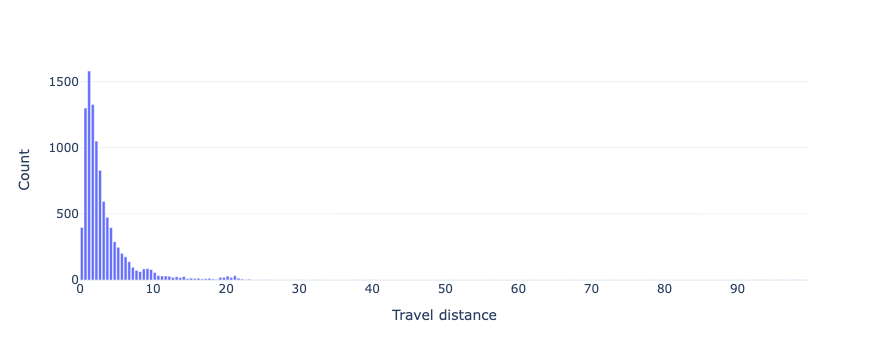

In [9]:
hist(table_short['distance'], "Travel distance", bins=200)

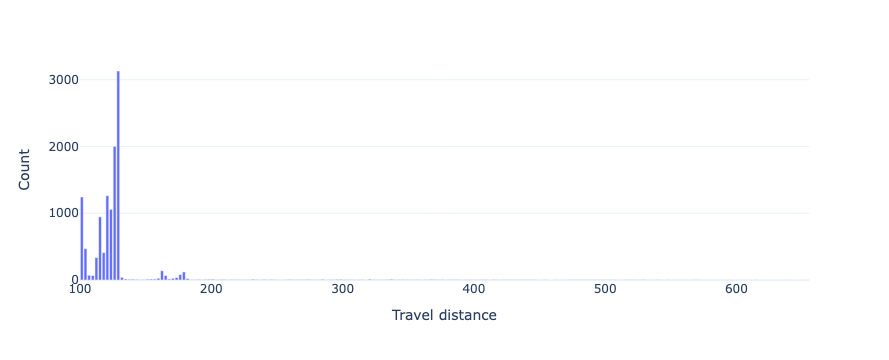

In [10]:
hist(table_long['distance'], "Travel distance", bins=200)

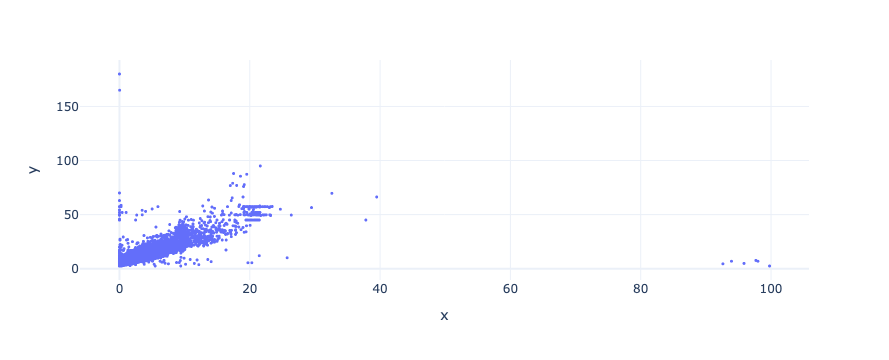

In [11]:
fig = px.scatter(
    x=table_short['distance'], 
    y=table_short['fare_amount']
)
fig.update_traces(marker={"size": 3})

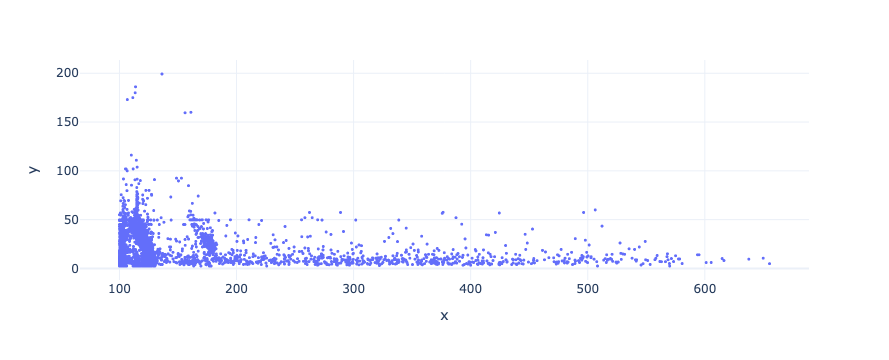

In [12]:
fig = px.scatter(
    x=table_long['distance'], 
    y=table_long['fare_amount']
)
fig.update_traces(marker={"size": 3})

## Landmarks

We have several NYC landmarks which we also add into our distance calculation.

In [13]:
landmarks = {
    "jfk_airport": (40.6446, -73.7797),
    "lag_airport": (40.7766, -73.8743),
    "new_airport": (40.6885, -74.1769),
    "center":      (40.7128, -74.0060),
    "manhattan":   (40.7767, -73.9713),
    "brooklyn":    (40.6782, -73.9442),
    "queens":      (40.7282, -73.7949),
    "bronx":       (40.8370, -73.8654),
    "staten":      (40.5790, -74.1515),
}

In [14]:
cols = {
    'idx': ds.field('idx'),
    'fare_amount': ds.field('fare_amount'),
    'passenger_count': ds.field('passenger_count'),
    'distance': compute_distance(
        ds.field('pickup_latitude'), ds.field('pickup_longitude'),
        ds.field('dropoff_latitude'), ds.field('dropoff_longitude')
    ),
}

for land_name, (lat, lon) in landmarks.items():
    for pt_name in ("dropoff", "pickup"):
        cols[f"{pt_name}_{land_name}_dist"] = 
            compute_distance(ds.field(pt_name + "_latitude"), 
                             ds.field(pt_name + "_longitude"),
                             ds.scalar(lat), ds.scalar(lon)
        )

table_feats = clean_dataset.to_table(columns=cols)
table_feats.shape

(54293690, 22)

In [15]:
table_feats.schema

idx: uint32
fare_amount: halffloat
passenger_count: uint8
distance: float
dropoff_jfk_airport_dist: float
pickup_jfk_airport_dist: float
dropoff_lag_airport_dist: float
pickup_lag_airport_dist: float
dropoff_new_airport_dist: float
pickup_new_airport_dist: float
dropoff_center_dist: float
pickup_center_dist: float
dropoff_manhattan_dist: float
pickup_manhattan_dist: float
dropoff_brooklyn_dist: float
pickup_brooklyn_dist: float
dropoff_queens_dist: float
pickup_queens_dist: float
dropoff_bronx_dist: float
pickup_bronx_dist: float
dropoff_staten_dist: float
pickup_staten_dist: float

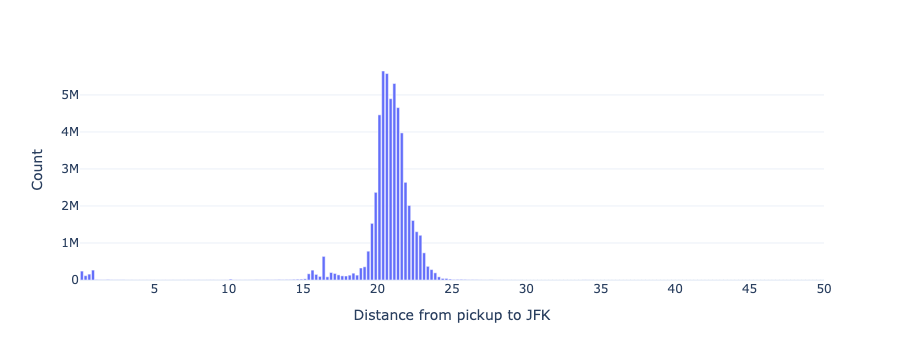

In [16]:
m = pc.less(table_feats['pickup_jfk_airport_dist'], 50)
hist(table_feats['pickup_jfk_airport_dist'].filter(m), 
     "Distance from pickup to JFK", bins=200)

## Datetime

We extract date components (dow, year, month, day and hour) and one-hot encode day of week.

In [17]:
table_feats = clean_dataset.to_table(
    columns={
        'idx': ds.field('idx'),
        'fare_amount': ds.field('fare_amount'),
        'passenger_count': ds.field('passenger_count'),
        'trip_dow': pc.day_of_week(
            ds.field('pickup_datetime')).cast(pa.uint8()),
        'trip_year': pc.year(
            ds.field('pickup_datetime')).cast(pa.uint16()),
        'trip_month': pc.month(
            ds.field('pickup_datetime')).cast(pa.uint8()),
        'trip_day': pc.day(
            ds.field('pickup_datetime')).cast(pa.uint8()),
        'trip_hour': pc.hour(
            ds.field('pickup_datetime')).cast(pa.uint8()),
    },
)
table_feats.shape

(54293690, 8)

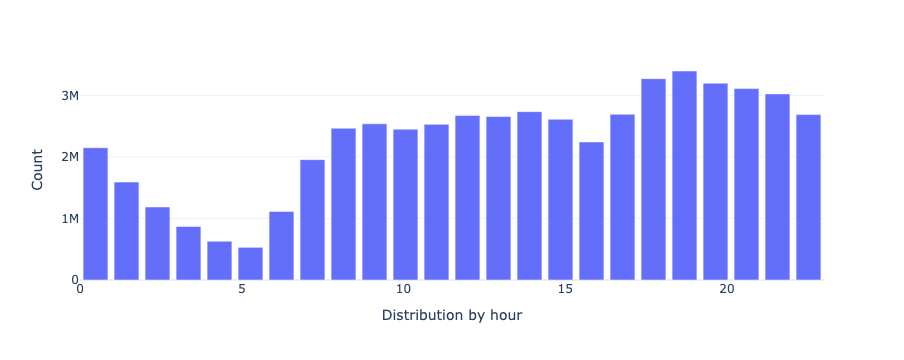

In [18]:
hist(table_feats['trip_hour'], "Distribution by hour", bins=24)

## Combine all together

In [19]:
plon = pc.field('pickup_longitude')
plat = pc.field('pickup_latitude')
dlon = pc.field('dropoff_longitude')
dlat = pc.field('dropoff_latitude')

res_plon = data.coord_transform(plon, 36, 46, plat)
res_plat = data.coord_transform(plat, -79, -70, plon)
res_dlon = data.coord_transform(dlon, 36, 46, dlat)
res_dlat = data.coord_transform(dlat, -79, -70, dlon)
res_dtime = data.parse_datetime(pc.field('pickup_datetime'))

res_dist = data.compute_distance(
    res_plat, res_plon, res_dlat, res_dlon)

In [20]:
cols = {
    'fare_amount': ds.field('fare_amount').cast(pa.float16()),
    'passenger_count': pc.if_else(
        ds.field('passenger_count') == 0,
        1, ds.field('passenger_count')
    ).cast(pa.uint8()),

    'travel_distance': res_dist,
    'trip_dow': pc.day_of_week(res_dtime).cast(pa.uint8()),
    'trip_year': pc.year(res_dtime).cast(pa.uint16()),
    'trip_month': pc.month(res_dtime).cast(pa.uint8()),
    'trip_day': pc.day(res_dtime).cast(pa.uint8()),
    'trip_hour': pc.hour(res_dtime).cast(pa.uint8()),
}

for land_name, (lat, lon) in data.LANDMARKS.items():
    for pt_name, (elat, elon) in (
        ("dropoff", (res_dlat, res_dlon)), 
        ("pickup", (res_plat, res_plon))
    ):
        cols[f"{pt_name}_{land_name}_dist"] = data.compute_distance(
            elat, elon, ds.scalar(lat), ds.scalar(lon)
        )

In [21]:
expr_filter = (
        data.filter_fare_amount(ds.field('fare_amount')) &
        (ds.field("passenger_count") <= 9) &
        data.coord_filter(plon) &
        data.coord_filter(plat) &
        data.coord_filter(dlon) &
        data.coord_filter(dlat) &
        (pc.sign(plat) != pc.sign(plon)) &
        pc.less(res_dist.cast(pa.float32()), 50)
)

table_full = dataset.to_table(columns=cols, filter=expr_filter)
table_full = data.add_index_column(table_full)
table_full.shape

(54273658, 27)

In [22]:
sys.getsizeof(table_full)

2937620672

In [23]:
table_full.schema

idx: uint32
fare_amount: halffloat
passenger_count: uint8
travel_distance: halffloat
trip_dow: uint8
trip_year: uint16
trip_month: uint8
trip_day: uint8
trip_hour: uint8
dropoff_jfk_airport_dist: halffloat
pickup_jfk_airport_dist: halffloat
dropoff_lag_airport_dist: halffloat
pickup_lag_airport_dist: halffloat
dropoff_new_airport_dist: halffloat
pickup_new_airport_dist: halffloat
dropoff_center_dist: halffloat
pickup_center_dist: halffloat
dropoff_manhattan_dist: halffloat
pickup_manhattan_dist: halffloat
dropoff_brooklyn_dist: halffloat
pickup_brooklyn_dist: halffloat
dropoff_queens_dist: halffloat
pickup_queens_dist: halffloat
dropoff_bronx_dist: halffloat
pickup_bronx_dist: halffloat
dropoff_staten_dist: halffloat
pickup_staten_dist: halffloat

# Data normalization

Normalizing the data (transforming it into zero mean and unit stddev) is 
an important step to speed up the convergence.

In [24]:
def normalize_table(table: pa.Table) -> pa.Table:
    res_dict = {}
    
    for col in table.column_names:
        col_data = table[col]
        if col == data.IDX_COL or col == data.TARGET_COL:
            res_dict[col] = col_data
            continue
        col_type = col_data.type            
        if pa.types.is_boolean(col_type):
            col_data = col_data.cast(pa.uint8())
            col_type = pa.float16()
        # there is a limited support of half float, need to cast
        if col_type == pa.float16():
            col_data = col_data.cast(pa.float32())
        m_mean = pc.mean(col_data)
        n = pc.divide(pc.subtract(col_data, m_mean), pc.stddev(col_data))
        if col_type == pa.float16():
            n = n.cast(col_type)
        else:
            n = n.cast(pa.float32())
        res_dict[col] = n
    return pa.table(res_dict)

In [29]:
norm_table = normalize_table(table_full)
pc.mean(norm_table['trip_hour']), pc.stddev(norm_table['trip_hour'])

(<pyarrow.DoubleScalar: -3.150915059476427e-11>,
 <pyarrow.DoubleScalar: 0.9999999915668913>)

In [31]:
sys.getsizeof(table_full), sys.getsizeof(norm_table)

(2937620672, 3860214008)

# Data storage

In [32]:
import pyarrow.feather as pf
pf.write_feather(norm_table, "data_v1.feather")